In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings("ignore")

In [3]:

def load_accuracy_from_log(method, log_dir, category, win_size, stride_size):
    """Load accuracy labels from JSON logs under one directory."""
    df = pd.DataFrame()
    if not os.path.isdir(log_dir):
        return df

    for acc_file in os.listdir(log_dir):
        if not acc_file.endswith(".json"):
            continue
        acc_path = os.path.join(log_dir, acc_file)
        with open(acc_path, "r") as f:
            json_data = json.load(f)

        # Extract content from OpenAI-style response["choices"][0]["message"]["content"]
        resp = json_data.get("response", {})
        choices = resp.get("choices", [])
        if not choices:
            continue
        msg = choices[0].get("message", {})
        content = str(msg.get("content", "")).strip()

        # Parse label from content, expected "Yes" or "No"
        if "Yes" in content:
            est = "Yes"
        elif "No" in content:
            est = "No"
        else:
            continue  # skip invalid label

        # Parse standard video name from filename
        video_name = os.path.splitext(os.path.basename(acc_path))[0]
        video_name_splits = video_name.split("_")
        if "anomaly" in video_name_splits:
            video_name = "_".join(video_name_splits[1:3])
        elif "normal" in video_name_splits:
            video_name = "_".join(video_name_splits[1:4])

        # Update dataframe; once a video is marked "Yes", keep it
        if video_name in df.index:
            if est == "Yes":
                df.loc[video_name, "est"] = "Yes"
        else:
            df.loc[video_name, "est"] = est

        df.loc[video_name, "category"] = category
        df.loc[video_name, "method"] = method
        df.loc[video_name, "win_size"] = win_size
        df.loc[video_name, "stride_size"] = stride_size
        df.loc[video_name, "label"] = "normal" if "normal" in video_name.lower() else "anomaly"

    if not df.empty:
        df = df.reset_index().rename(columns={"index": "video_name"})
    df.ordered_cols = ["method", "win_size", "stride_size", "category", "video_name", "label", "est"]
    df = df[df.ordered_cols]
    df = df.groupby(df.columns.tolist(), as_index=False).first()    
    df.to_csv(f"{log_dir}/parsed_accuracy.csv", index=False)    
    return df

def parse_accuracy_log(model_name, with_cacheblend_dir, without_cacheblend_dir, win_sizes, stride_sizes, fps, categorys):
    """Parse accuracy logs for all configurations and write to a CSV file."""
    for win_size in win_sizes:
        for stride_size in stride_sizes:
            results = []
            for category in categorys:
                # with CacheBlend
                acc_dir_with = os.path.join(with_cacheblend_dir, f"anomaly_win{win_size}s_stride{stride_size}pct_fps{fps}", category)
                print(f"Processing {acc_dir_with}")
                df_with = load_accuracy_from_log("w_cacheblend", acc_dir_with, category, win_size, stride_size)
                if not df_with.empty:
                    results.append(df_with)
                # without CacheBlend
                acc_dir_without = os.path.join(without_cacheblend_dir, f"anomaly_win{win_size}s_stride{stride_size}pct_fps{fps}", category)
                df_without = load_accuracy_from_log("without_cacheblend", acc_dir_without, category, win_size, stride_size)
                if not df_without.empty:
                    results.append(df_without)

            if not results:
                print(f"No accuracy logs found for win{win_size}, stride{stride_size}, CSV not generated.")
                continue

            results_df = pd.concat(results, axis=0, ignore_index=True)
            results_df = results_df.sort_values(by=["method", "category", "video_name"])

            # Build/repair labels before pivot so KeyError on missing label is avoided
            if "label" not in results_df.columns:
                results_df["label"] = results_df["video_name"].apply(lambda x: "normal" if "normal" in str(x).lower() else "anomaly")

            label_df = (
                results_df[["win_size", "stride_size", "category", "video_name", "label"]]
                .drop_duplicates(subset=["win_size", "stride_size", "category", "video_name"])
            )
            label_df["ground_truth"] = label_df["label"].apply(lambda x: "No" if x == "normal" else "Yes")
            label_df = label_df.drop(columns=["label"])

            results_df = results_df.pivot_table(
                index=["win_size", "stride_size", "category", "video_name"],
                columns="method",
                values="est",
                aggfunc="first"
            ).reset_index()

            results_df = results_df.merge(
                label_df,
                on=["win_size", "stride_size", "category", "video_name"],
                how="left",
            )

            out_dir = f"../csv/{model_name}/small_dataset/"
            os.makedirs(out_dir, exist_ok=True)
            out_csv = os.path.join(out_dir, f"win{win_size}_stride{stride_size}_accuracy_results.csv")
            results_df.to_csv(out_csv, index=False)
            print(f"Saved {len(results_df)} rows to {out_csv}")


In [4]:
def plot_metrics_bar_chart(model_name, win_size, stride_size, categorys, methods, method_labels, csv_file, output_file):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    assert len(methods) == len(method_labels), "methods and method_labels must have same length"
    method_to_label = dict(zip(methods, method_labels))

    df = pd.read_csv(csv_file)

    # compute Precision, Recall, F1-score per (method, category)
    summary = []
    for method in methods:
        if method not in df.columns:
            print(f"[WARN] method column not found in CSV: {method}")
            continue
        for category in categorys:
            df_subset = df[df["category"] == category]
            if df_subset.empty:
                continue

            # normalize possible whitespace/case (optional but robust)
            pred = df_subset[method].astype(str).str.strip()
            gt = df_subset["ground_truth"].astype(str).str.strip()

            tp = ((pred == "Yes") & (gt == "Yes")).sum()
            fp = ((pred == "Yes") & (gt == "No")).sum()
            fn = ((pred == "No") & (gt == "Yes")).sum()

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

            summary.append({
                "method": method,
                "category": category,
                "Precision": precision,
                "Recall": recall,
                "F1-score": f1_score,
            })

    if not summary:
        print("No valid data to plot.")
        return

    summary_df = pd.DataFrame(summary)

    metrics = ["Precision", "Recall", "F1-score"]
    categorys_with_avg = list(categorys) + ["Avg"]

    x = np.arange(len(categorys_with_avg))
    width = 0.8 / max(len(methods), 1)

    fig, axes = plt.subplots(
        1, len(metrics),
        figsize=(3.4 * len(metrics), 3.2),
        sharey=False,
        dpi=150
    )
    if len(metrics) == 1:
        axes = [axes]

    # discrete colors (stable & distinct)
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % cmap.N) for i in range(len(methods))]

    for m_idx, metric in enumerate(metrics):
        ax = axes[m_idx]

        pivot = (summary_df
                 .pivot_table(index="category", columns="method", values=metric, aggfunc="mean")
                 .reindex(index=categorys, columns=methods))

        # Avg over categories (ignore missing categories for each method)
        pivot.loc["Avg"] = pivot.mean(axis=0, skipna=True)
        pivot = pivot.reindex(index=categorys_with_avg).fillna(0.0)

        ymax = float(pivot.max().max()) if pivot.size else 0.0
        ylim_top = max(ymax * 1.25, 0.12)  # give headroom for text

        for j, method in enumerate(methods):
            if method not in pivot.columns:
                continue
            y = pivot[method].values
            offsets = (j - (len(methods) - 1) / 2) * width

            # Put legend labels only once (avoid duplicate legends)
            label = method_to_label.get(method, method) if m_idx == 0 else None

            ax.bar(
                x + offsets, y, width,
                label=label,
                color=colors[j],
                edgecolor="none"
            )

            # annotate bars (use relative offset)
            text_dy = 0.02 * ylim_top
            for i, v in enumerate(y):
                ax.text(
                    x[i] + offsets, v + text_dy,
                    f"{v:.2f}",
                    ha="center", va="bottom",
                    fontsize=8, rotation=90,
                    clip_on=False
                )

        ax.set_ylim(0, ylim_top)
        ax.set_xticks(x)
        ax.set_xticklabels(categorys_with_avg, rotation=45, ha="right")
        ax.set_ylabel(metric)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    # title + legend (more robust)
    fig.suptitle(f"{model_name}, win={win_size}, stride={stride_size}%", y=1.06, fontsize=10)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02),
                   frameon=False, ncol=min(len(labels), 4))

    fig.tight_layout()
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()

In [5]:
def load_time_from_log(model_name, methods, log_dirs, categorys, win_size, stride_size):
    """Load time from CSV logs under multiple directories and merge into a result CSV."""
    all_rows = []

    for method, log_dir in zip(methods, log_dirs):
        if not os.path.isdir(log_dir):
            print(f"[WARN] Log dir not found, skip: {log_dir}")
            continue

        for category in categorys:
            time_file = os.path.join(
                log_dir,
                f"anomaly_win{win_size}s_stride{stride_size}pct_fps2.0",
                category,
                f"request_times_win{win_size}_stride{stride_size/100}.csv",
            )
            print(f"Processing {time_file}")
            if not os.path.isfile(time_file):
                print(f"[WARN] Time file not found, skip: {time_file}")
                continue

            df_time = pd.read_csv(time_file)
            # delete the first row if it contains warm-up time
            df_time = df_time.iloc[1:]
            for _, row in df_time.iterrows():
                video_name = os.path.splitext(os.path.basename(row["video_path"]))[0]
                all_rows.append({
                    "video_name": video_name,
                    "time_seconds": row["duration_seconds"],
                    "category": category,
                    "method": method,
                    "win_size": win_size,
                    "stride_size": stride_size,
                })

    if not all_rows:
        print("[WARN] No time records loaded.")
        return pd.DataFrame()

    df = pd.DataFrame(all_rows)
    df.sort_values(by=["method", "category", "video_name"], inplace=True)

    out_csv = f"../csv/{model_name}/small_dataset/win{win_size}_stride{stride_size}_time_results.csv"
    if os.path.exists(out_csv):
        df_existing = pd.read_csv(out_csv)
        df = pd.concat([df_existing, df], axis=0, ignore_index=True)

    # Remove duplicates and average time_seconds for the same (video, method, category, win/stride)
    df = (
        df.groupby(
            ["video_name", "method", "category", "win_size", "stride_size"],
            as_index=False
        )["time_seconds"].mean()
    )

    # Pivot: one column per method, values = time_seconds
    df = df.pivot_table(
        index=["video_name", "category", "win_size", "stride_size"],
        columns="method",
        values="time_seconds",
        aggfunc="first"
    ).reset_index()
    df.columns.name = None  # clean column index name

    # Optional: rename method columns if they exist
    rename_map = {}
    if "with_cacheblend" in df.columns:
        rename_map["with_cacheblend"] = "w_cacheblend"
    if "without_cacheblend" in df.columns:
        rename_map["without_cacheblend"] = "without_cacheblend"
    df.rename(columns=rename_map, inplace=True)
    # delete the video_name column
    df.drop(columns=["video_name"], inplace=True)
    # Group by category, win_size, stride_size and compute mean times
    df = df.groupby(["category", "win_size", "stride_size"], as_index=False).mean()
    # add a new column ratio indicating time reduction ratio of w_cacheblend over without_cacheblend
    if "w_cacheblend" in df.columns and "without_cacheblend" in df.columns:
        df["time_reduction_ratio"] = (df["without_cacheblend"] - df["w_cacheblend"]) / df["without_cacheblend"]
    df.to_csv(out_csv, index=False)
    print(f"Loaded and saved {len(df)} records to {out_csv}")
    return df

In [6]:
def plot_latency_bar_chart(model_name, win_size, stride_size, categorys, methods, method_labels, csv_file, output_file):
    import numpy as np, pandas as pd, matplotlib.pyplot as plt
    assert len(methods) == len(method_labels)
    m2l = dict(zip(methods, method_labels))

    df = pd.read_csv(csv_file)
    cats = list(categorys) + ["Avg"]
    x = np.arange(len(cats))
    w = 0.8 / max(len(methods), 1)
    fig, ax = plt.subplots(figsize=(5.6, 3.2), dpi=150)

    cmap = plt.get_cmap("tab20")
    cols = [cmap(i % cmap.N) for i in range(len(methods))]

    bars_all = []
    for j, m in enumerate(methods):
        if m not in df.columns: 
            print(f"[WARN] missing col: {m}"); continue
        y = df.set_index("category").reindex(categorys)[m].to_numpy(float)
        yavg = np.nanmean(y) if y.size else 0.0
        yavg = 0.0 if np.isnan(yavg) else yavg
        y = np.r_[y, yavg]
        off = (j - (len(methods)-1)/2) * w
        ax.bar(x + off, y, w, color=cols[j], label=m2l.get(m, m), edgecolor="none", zorder=2)
        bars_all.append(y)

    ymax = float(np.nanmax(np.r_[bars_all])) if bars_all else 0.0
    ax.set_ylim(0, max(0.2, ymax * 1.28))

    # ---- ratio: place at the right edge of each category-group to avoid overlap with bars
    if "time_reduction_ratio" in df.columns:
        yr = df.set_index("category").reindex(categorys)["time_reduction_ratio"].to_numpy(float) * 100.0
        ravg = np.nanmean(yr) if yr.size else 0.0
        ravg = 0.0 if np.isnan(ravg) else ravg
        yr = np.r_[yr, ravg]

        ax2 = ax.twinx()
        group_right = x + 0.15*w          # right edge of the bar group + small extra offset
        ax2.plot(group_right, yr, marker="o", linewidth=1.5, label="Reduction Ratio", zorder=5, color=plt.cm.tab20(len(methods)+1))

        rmin, rmax = float(np.nanmin(yr)), float(np.nanmax(yr))
        pad = max((rmax - rmin) * 0.25, 5.0)
        lo, hi = rmin - pad, rmax + pad
        if hi - lo < 20: 
            c = (hi + lo) / 2; lo, hi = c - 15, c + 15
        ax2.set_ylim(lo, hi)
        ax2.set_ylabel("Reduction Ratio (%)")
        ax2.grid(False)  # 避免双重网格显乱

        dy = 0.02 * (hi - lo)
        for xi, v in zip(group_right, yr):
            if np.isnan(v): continue
            ax2.text(xi, v + dy, f"{v:.2f}%", ha="center", va="bottom", fontsize=8, clip_on=False)

        ax2.legend(loc="upper right", frameon=False)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=45, ha="right")
    ax.set_ylabel("Avg. Latency (s)")
    ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

    h, l = ax.get_legend_handles_labels()
    if h:
        fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, 1.05),
                   frameon=False, ncol=min(len(l), 4))
    fig.suptitle(f"{model_name}, win={win_size}, stride={stride_size}%", y=1.12, fontsize=10)

    fig.tight_layout()
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()

In [7]:
def plot_prf_trend_by_stride(model_name, win_size, stride_sizes,
                             methods, method_labels, output_file,
                             stride_col="stride_size"):
    import numpy as np, pandas as pd, matplotlib.pyplot as plt
    assert len(methods) == len(method_labels)
    m2l = dict(zip(methods, method_labels))
    stride_sizes = list(stride_sizes)
    x = np.array(stride_sizes, dtype=float)

    # ---------- metric computation ----------
    def prf_from_df(d, m):
        pred, gt = d[m], d["ground_truth"]
        tp = ((pred == "Yes") & (gt == "Yes")).sum()
        fp = ((pred == "Yes") & (gt == "No")).sum()
        fn = ((pred == "No") & (gt == "Yes")).sum()
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * p * r) / (p + r) if (p + r) > 0 else 0.0
        return p, r, f1

    metrics = ["Precision", "Recall", "F1-score"]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), dpi=150, sharex=True)

    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % cmap.N) for i in range(len(methods))]

    # ---------- main loop ----------
    for midx, metric in enumerate(metrics):
        ax = axes[midx]
        ymax = 0.0

        for j, m in enumerate(methods):
            y = []
            for s in stride_sizes:
                df = pd.read_csv(
                    f"../csv/{model_name}/small_dataset/win{win_size}_stride{s}_accuracy_results.csv"
                )
                p, r, f1 = prf_from_df(df, m)
                y.append({"Precision": p, "Recall": r, "F1-score": f1}[metric])

            y = np.array(y, dtype=float)
            if np.isfinite(y).any():
                ymax = max(ymax, float(np.nanmax(y)))

            ax.plot(
                x, y, marker="o", linewidth=1.6,
                label=m2l.get(m, m), color=colors[j]
            )

        ax.set_title(metric)
        ax.set_xlabel("Stride size (%)")
        ax.set_ylabel(metric)
        ax.set_xticks(x)
        ax.set_ylim(0, max(0.12, min(1.0, ymax * 1.25)))
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        if midx == 2:
            ax.legend(loc="lower right", frameon=False)

    fig.suptitle(f"{model_name}, win={win_size}, PRF vs stride", y=1.02, fontsize=10)
    fig.tight_layout()
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()


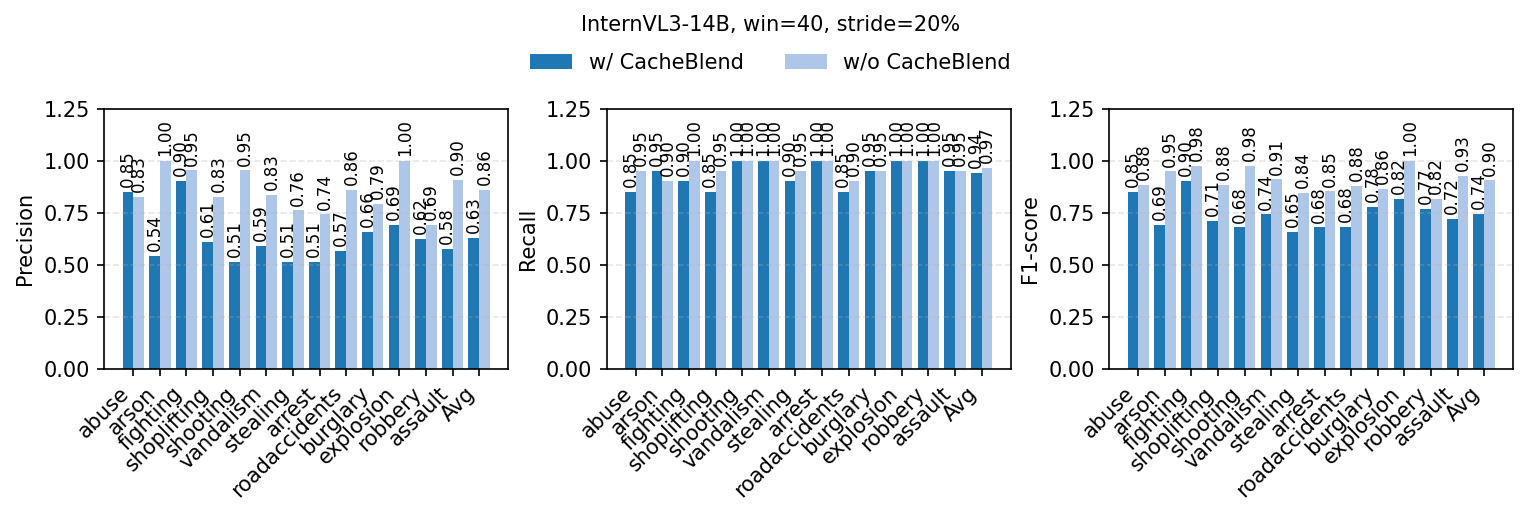

In [ ]:
model_name="InternVL3-14B"
# model_name="Qwen3-VL-32B-Instruct"
# model_name="Qwen3-VL-8B-Thinking"
categorys = ["abuse", "arson", "fighting", "shoplifting", "shooting", "vandalism", "stealing"]
categorys = ["abuse", "arson", "fighting", "shoplifting", "shooting", "vandalism", "stealing", "arrest", "roadaccidents", "burglary", "explosion", "robbery", "assault"]
with_cacheblend_dir = f"/root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs/{model_name}/small_dataset"
without_cacheblend_dir = f"/root/workspace/lmcache_multimodal/scripts_test_video/results_analysis/logs_baselines/{model_name}/small_dataset"
methods = ["w_cacheblend", "without_cacheblend"]
method_labels = ["w/ CacheBlend", "w/o CacheBlend"]   
dirs = [with_cacheblend_dir, without_cacheblend_dir]
win_sizes = [40]
stride_sizes = [20]
fps = 2.0

# parse_accuracy_log(model_name, with_cacheblend_dir, without_cacheblend_dir, win_sizes, stride_sizes, fps, categorys)

for win_size in win_sizes:
    for stride_size in stride_sizes:
        plot_metrics_bar_chart(
            model_name,
            win_size,
            stride_size,
            categorys, 
            methods, 
            method_labels, 
            f"../csv/{model_name}/small_dataset/win{win_size}_stride{stride_size}_accuracy_results.csv", 
            f"../pdfs/{model_name}/small_dataset_win{win_size}_stride{stride_size}_accuracy_metrics_bar_chart.pdf")
        
        # load_time_from_log(model_name,methods, dirs, categorys, win_size, stride_size)
        # plot_latency_bar_chart(
        #     model_name,
        #     win_size,
        #     stride_size,
        #     categorys,
        #     methods,
        #     method_labels,
        #     f"../csv/{model_name}/small_dataset/win{win_size}_stride{stride_size}_time_results.csv",
        #     f"../pdfs/{model_name}/small_dataset_win{win_size}_stride{stride_size}_latency_bar_chart.pdf"
        # )
    # plot_prf_trend_by_stride(
    #     model_name,
    #     win_size,
    #     stride_sizes,
    #     methods,
    #     method_labels,    
    #     f"../pdfs/{model_name}/small_dataset_win{win_size}_latency_trend_by_stride.pdf",
    #     stride_col="stride_size"
    # )    